# Greatest Euclidean Distance

Given a list of points in a high dimensional space, find the pair of points with the greatest Euclidean distance between them.

## Setup

### Import libraries

In [125]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial import distance

### Define data

In [126]:
points = pd.DataFrame({
    'Name': [c for c in 'ABCDEFGH'],
    '_i': np.random.randint(1, 6, 8),
    '_j': np.random.randint(1, 6, 8),
    '_k': np.random.randint(1, 6, 8),
    '_l': np.random.randint(1, 6, 8),
    '_m': np.random.randint(1, 6, 8),
    '_n': np.random.randint(1, 6, 8),
})
features = ['_i', '_j', '_k', '_l', '_m', '_m']
points

,Name,_i,_j,_k,_l,_m,_n
0,A,5,5,5,4,1,3
1,B,2,4,3,5,3,1
2,C,3,1,3,2,3,4
3,D,4,5,2,3,1,4
4,E,5,2,2,5,5,5
5,F,4,5,1,4,4,3
6,G,3,4,3,3,1,1
7,H,2,3,1,5,5,5


## Compute distances

In [127]:
distances = pd.DataFrame(distance.cdist(points[features], points[features], 'eu'))
distances

,0,1,2,3,4,5,6,7
0,0.000000,4.795832,6.000000,3.316625,7.141428,5.916080,3.162278,7.874008
1,4.795832,0.000000,4.358899,4.242641,4.690416,3.464102,3.605551,3.605551
2,6.000000,4.358899,0.000000,5.196152,4.795832,5.196152,4.242641,5.099020
3,3.316625,4.242641,5.196152,0.000000,6.782330,4.472136,1.732051,6.708204
4,7.141428,4.690416,4.795832,6.782330,0.000000,3.741657,6.708204,3.316625
5,5.916080,3.464102,5.196152,4.472136,3.741657,0.000000,5.000000,3.316625
6,3.162278,3.605551,4.242641,1.732051,6.708204,5.000000,0.000000,6.480741
7,7.874008,3.605551,5.099020,6.708204,3.316625,3.316625,6.480741,0.000000


## Visualize distances with a heatmap

<Axes: >

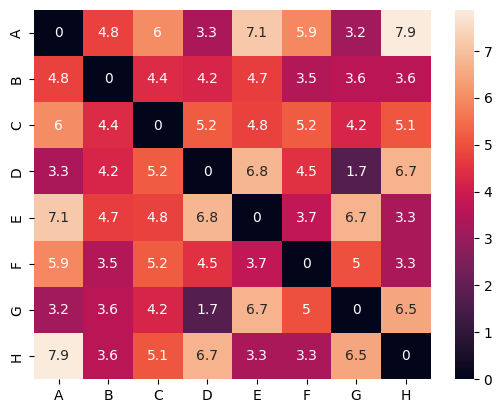

In [128]:
sns.heatmap(distances, annot=True, xticklabels=points['Name'], yticklabels=points['Name'])

## Find the max distance

In [129]:
max_distance = distances.max().max()
print(f'Max distance: {max_distance}')

Max distance: 7.874007874011811


## Find and name the points pairs with that distance

In [130]:
for i in range(len(points)):
    for j in range(i+1, len(points)):
        if distances.iloc[i,j] == max_distance:
            print(f'{points.iloc[i,0]} and {points.iloc[j,0]} are the farthest apart.')

A and H are the farthest apart.
